In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])

In [3]:
df.columns=['Class label','Alchol','malic acid']

In [4]:
df.head()

,Class label,Alchol,malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alchol', ylabel='Density'>

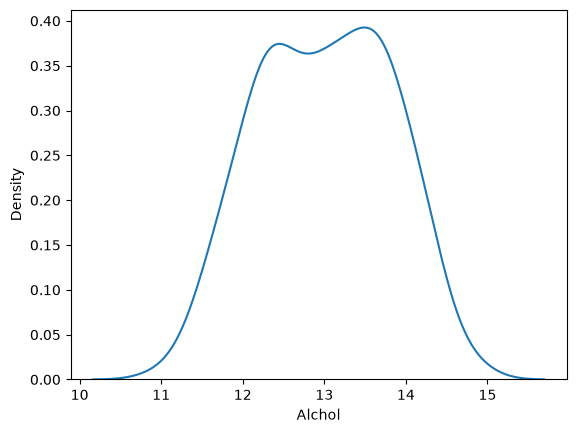

In [5]:
sns.kdeplot(df['Alchol'])

<Axes: xlabel='malic acid', ylabel='Density'>

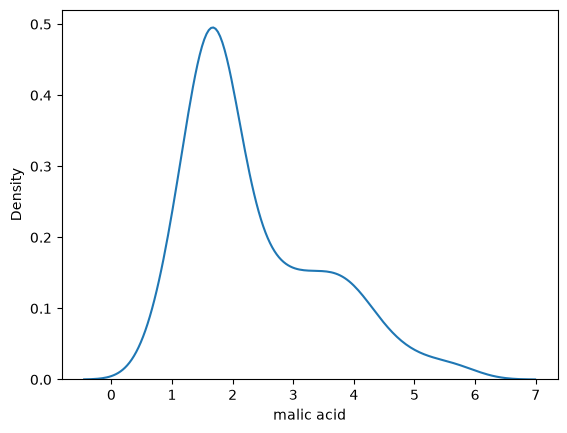

In [6]:
sns.kdeplot(df['malic acid'])

<Axes: xlabel='Alchol', ylabel='malic acid'>

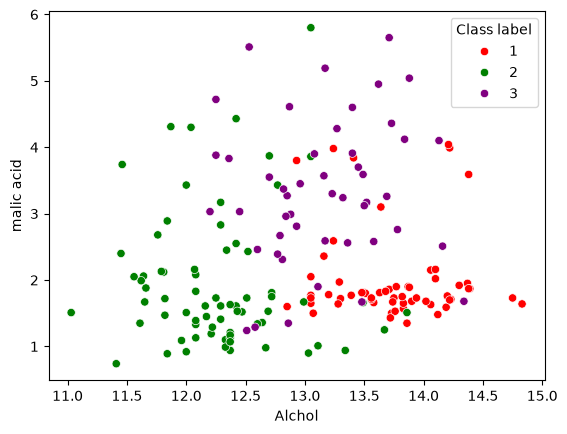

In [7]:
color_dict={1:'red',2:'green',3:'purple'}
sns.scatterplot(x=df['Alchol'],y=df['malic acid'],hue=df['Class label'],palette=color_dict)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Class label',axis=1),df['Class label'],test_size=0.3,random_state=0)

In [9]:
X_train.shape,X_test.shape

((124, 2), (54, 2))

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [12]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [14]:
np.round(X_train.describe(),1)

,Alchol,malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [15]:
np.round(X_train_scaled.describe(),1)

,Alchol,malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


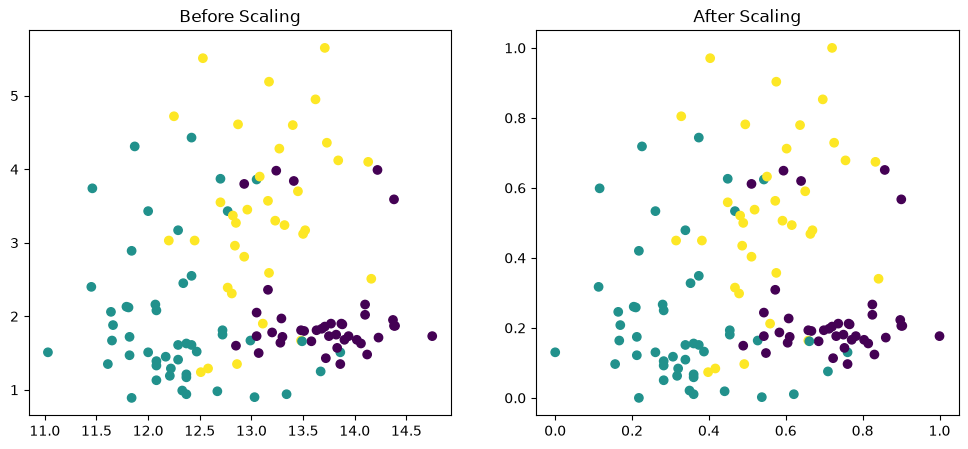

In [19]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['Alchol'],X_train['malic acid'],c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alchol'],X_train_scaled['malic acid'],c=y_train)
ax2.set_title('After Scaling')
plt.show()

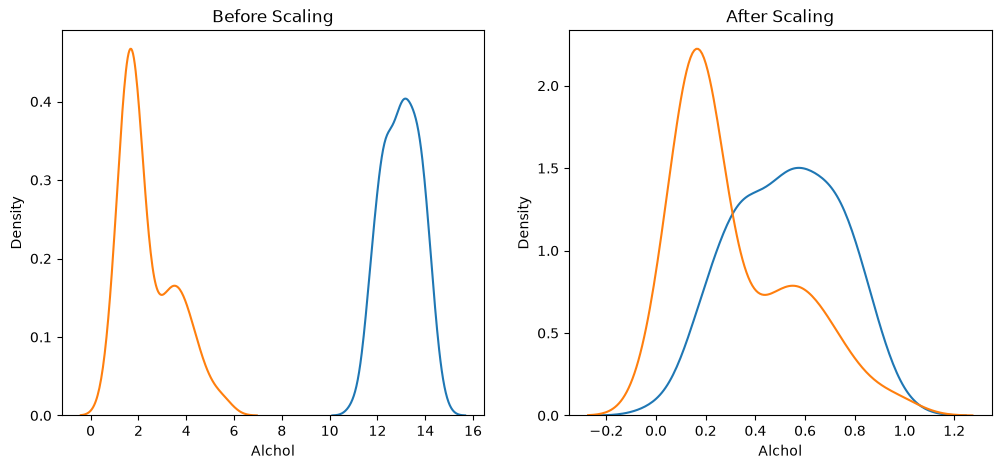

In [20]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alchol'],ax=ax1)
sns.kdeplot(X_train['malic acid'],ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Alchol'],ax=ax2)
sns.kdeplot(X_train_scaled['malic acid'],ax=ax2)
plt.show()